# HIS-05 · Monitor de Saturación
**Data Scientist A — Forecasting de llegadas a Urgencias**

Predecir el volumen horario de llegadas de pacientes (`pacientes_llegando`) para detectar saturación anticipadamente.

Stack: `XGBRegressor` + `TimeSeriesSplit`

Métricas: MAE, RMSE, R²

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 2. Carga de datos

Fuentes: `NOTAMEDICAURG.parquet` (llegadas y proxy de espera) y `TRIAGE.parquet` (severidad).

In [ ]:
df_nota = pd.read_parquet('notamedicaurg.parquet', engine='fastparquet')
df_triage_raw = pd.read_parquet('triage.parquet', engine='fastparquet')

print('NOTAMEDICAURG:', df_nota.shape)
print('TRIAGE:', df_triage_raw.shape)
display(df_nota.head(3))

NOTAMEDICAURG: (22878, 70)
TRIAGE        : (9942, 21)


,Indice,Expediente,Edad,Sexo,ClaveIngreso,Fecha,Hora,Usuario,Medico,Especialidad,LlegadaServicio,MotivoConsulta,Triage,AtMed_Hora,Subjetivo,Objetivo,Apreciativo,Diag1,DesDiag1,Diag2,DesDiag2,Pplan,Pronostico,Accidente,Observacion,...,prox_cita1,MotivoAtencion,Diag1Sal,DesDiag1Sal,Responsable,NombreResp,EstatusReg,DiagIng2,DesDiagIng2,DiagIng3,DesDiagIng3,Diag4,DesDiag4,Diag5,DesDiag5,Diag6,DesDiag6,MedicoLegal,MedLegImp,IndiceSV,SoloCEX,LugarHecho,CalleAvenida,Colonia,Municipio
0,25.0000,00000000000000009789,30A,M,CZM 11996 1,20241004,123712,UCN,456,URGENC,1,DOLOR ABDOMINAL ...,N,,Reason for admission: \nAbdominal pain \n\nDir...,Physical examination \nUpon his arrival to the...,The patient is with obstructive lithiasis n th...,N201,LITIASIS URETERAL ...,,...,,Bueno para la función ...,,1,...,,,,...,,...,1,,...,,...,,...,,...,,...,N,N,0,,...,...,...,...
1,26.0000,00000000000000009798,70A,F,CZM 12024 1,20241004,141909,UCN,456,URGENC,0,CONTUSION EN TORAX ...,M,,Reason for admission: \nChest contusion \n\nDi...,Physical examination \nUpon her arrival to the...,The patient is with chest contusion and left k...,S202,Contusión del tórax ...,J84.,Other interstitial pulmonary diseases ...,,Reservado ...,O,1,...,,,,...,,...,2,,...,,...,,...,J90X,Derrame pleural no clasificado en otra parte ...,,...,N,N,0,,...,...,...,...
2,28.0000,00000000000000009798,70A,F,CZM 12024 1,20241004,150125,UCN,456,URGENC,0,CONTUSION EN TORAX ...,M,,Reason for admission: \nChest contusion \n\nDi...,Physical examination \nUpon her arrival to the...,The patient is with chest contusion and left k...,S202,Contusión del tórax ...,J84.,Other interstitial pulmonary diseases ...,,Reservado ...,O,1,...,,,,...,,...,1,,...,,...,,...,J90X,Derrame pleural no clasificado en otra parte ...,,...,N,N,0,,...,...,...,...


## 3. Limpieza y construcción de timestamps

Construimos `arrival_datetime` y `note_datetime` a partir de las columnas de fecha y hora.
El proxy de espera es `note_datetime − arrival_datetime` (en minutos); se marca como inválido
si es negativo o mayor a 24 horas.

### 3.1 Parser robusto de fecha + hora

In [6]:
def parse_dt(df, date_col, time_col):
    """Combina columna de fecha y hora (formato HHMMSS o numérico) en datetime."""
    d = df[date_col].astype(str).str.strip()
    t = (df[time_col].astype(str)
                     .str.split('.').str[0]
                     .str.strip()
                     .str.zfill(6))
    d = d.replace(['nan', 'NaT', 'None', ''], pd.NA)
    t = t.replace(['nan', 'NaT', 'None', '000000', '0', '      '], pd.NA)
    combined = (d.astype(str) + ' ' + t.astype(str)).str.strip()
    combined = combined.replace(['nan nan', 'nan <NA>', '<NA> nan', '<NA> <NA>'], pd.NA)
    return pd.to_datetime(combined, errors='coerce')

### 3.2 Limpieza de NOTAMEDICAURG

In [7]:
nota = df_nota.copy()

# Estandarizar strings
str_cols = nota.select_dtypes('object').columns
nota[str_cols] = nota[str_cols].apply(lambda s: s.str.strip()).replace('', pd.NA)

# Timestamps
nota['arrival_datetime'] = parse_dt(nota, 'Llegada_Fecha', 'Llegada_Hora')
nota['note_datetime']    = parse_dt(nota, 'Llegada_Fecha', 'Hora')

# Proxy de espera
nota['wait_proxy_min'] = (
    (nota['note_datetime'] - nota['arrival_datetime']).dt.total_seconds() / 60
)
nota['valid_wait_proxy'] = (
    nota['wait_proxy_min'].notna() &
    (nota['wait_proxy_min'] >= 0) &
    (nota['wait_proxy_min'] <= 1440)
).astype(int)

# Filtro de fechas operativas (eliminar outliers de captura tipo 1963)
nota = nota[
    nota['arrival_datetime'].between('2020-01-01', '2026-02-27')
].copy().reset_index(drop=True)

print('Registros válidos:', len(nota))
print('Proxies válidos  :', nota['valid_wait_proxy'].sum())
display(nota[['arrival_datetime','note_datetime','wait_proxy_min','valid_wait_proxy']].head(3))

Registros válidos: 22845
Proxies válidos  : 20946


,arrival_datetime,note_datetime,wait_proxy_min,valid_wait_proxy
0,2024-10-04 10:55:39,2024-10-04 12:37:12,101.5500,1
1,2024-10-04 12:36:37,2024-10-04 14:19:09,102.5333,1
2,2024-10-04 12:36:37,2024-10-04 15:01:25,144.8000,1


### 3.3 Limpieza de TRIAGE

In [8]:
triage = df_triage_raw.copy()
str_cols = triage.select_dtypes('object').columns
triage[str_cols] = triage[str_cols].apply(lambda s: s.str.strip()).replace('', pd.NA)

triage['triage_datetime'] = parse_dt(triage, 'Fecha', 'Hora')
triage = triage.dropna(subset=['triage_datetime']).copy()

triage_map = {'A': 'A', 'C': 'C', 'E': 'E', 'M': 'M', 'N': 'N'}
triage['triage_clean'] = triage['Triage'].map(triage_map) if 'Triage' in triage.columns else pd.NA

triage = triage[
    triage['triage_datetime'].between('2020-01-01', '2026-02-27')
].copy().reset_index(drop=True)

print('Triage válidos:', len(triage))
display(triage[['triage_datetime','triage_clean']].head(3))

Triage válidos: 9941


,triage_datetime,triage_clean
0,2024-10-04 11:26:37,N
1,2024-10-04 12:43:39,M
2,2024-10-05 09:15:57,M


## 4. Construcción de `master_table_his05`

Agregamos a nivel hora de operación:
- `pacientes_llegando` — conteo de llegadas (target)
- `tiempo_espera` / `tiempo_espera_mediana` — proxy de espera promedio/mediana (solo válidos)
- `triage_{A,C,E,M,N}` — conteo horario por nivel de severidad
- Variables temporales: hora, día de semana, mes, fin de semana

In [9]:
# ── Agregación horaria de urgencias ──
nota['hour'] = nota['arrival_datetime'].dt.floor('h')

hourly_urg = nota.groupby('hour').agg(
    pacientes_llegando    = ('Indice', 'count'),
    tiempo_espera         = ('wait_proxy_min',
                              lambda x: x[nota.loc[x.index, 'valid_wait_proxy'] == 1].mean()),
    tiempo_espera_mediana = ('wait_proxy_min',
                              lambda x: x[nota.loc[x.index, 'valid_wait_proxy'] == 1].median()),
    wait_proxy_valid_count= ('valid_wait_proxy', 'sum'),
).reset_index().rename(columns={'hour': 'timestamp'})

# ── Agregación horaria de triage ──
triage['hour'] = triage['triage_datetime'].dt.floor('h')
hourly_triage = (
    triage.groupby(['hour', 'triage_clean'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={'hour': 'timestamp'})
)
hourly_triage.columns = (
    ['timestamp'] + [f'triage_{c}' for c in hourly_triage.columns[1:]]
)

# ── Join temporal ──
master = hourly_urg.merge(hourly_triage, on='timestamp', how='left')
triage_cols = [c for c in master.columns if c.startswith('triage_')]
master[triage_cols] = master[triage_cols].fillna(0).astype(int)

# ── Variables temporales ──
master['hour_of_day']  = master['timestamp'].dt.hour
master['day_of_week']  = master['timestamp'].dt.dayofweek
master['month']        = master['timestamp'].dt.month
master['is_weekend']   = (master['day_of_week'] >= 5).astype(int)
master['week_of_year'] = master['timestamp'].dt.isocalendar().week.astype(int)

master = master.sort_values('timestamp').reset_index(drop=True)

print('master_table_his05:', master.shape)
print('Columnas:', master.columns.tolist())
display(master.head(5))

master_table_his05: (3120, 15)
Columnas: ['timestamp', 'pacientes_llegando', 'tiempo_espera', 'tiempo_espera_mediana', 'wait_proxy_valid_count', 'triage_A', 'triage_C', 'triage_E', 'triage_M', 'triage_N', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'week_of_year']


,timestamp,pacientes_llegando,tiempo_espera,tiempo_espera_mediana,wait_proxy_valid_count,triage_A,triage_C,triage_E,triage_M,triage_N,hour_of_day,day_of_week,month,is_weekend,week_of_year
0,2024-10-04 10:00:00,1,101.5500,101.5500,1,0,0,0,0,0,10,4,10,0,40
1,2024-10-04 12:00:00,2,123.6667,123.6667,2,0,0,0,1,0,12,4,10,0,40
2,2024-10-04 13:00:00,3,129.7556,138.1667,3,0,0,0,1,0,13,4,10,0,40
3,2024-10-05 09:00:00,1,28.6667,28.6667,1,0,0,0,1,0,9,5,10,1,40
4,2024-10-05 17:00:00,1,244.0000,244.0000,1,0,0,0,0,0,17,5,10,1,40


## 5. Análisis exploratorio

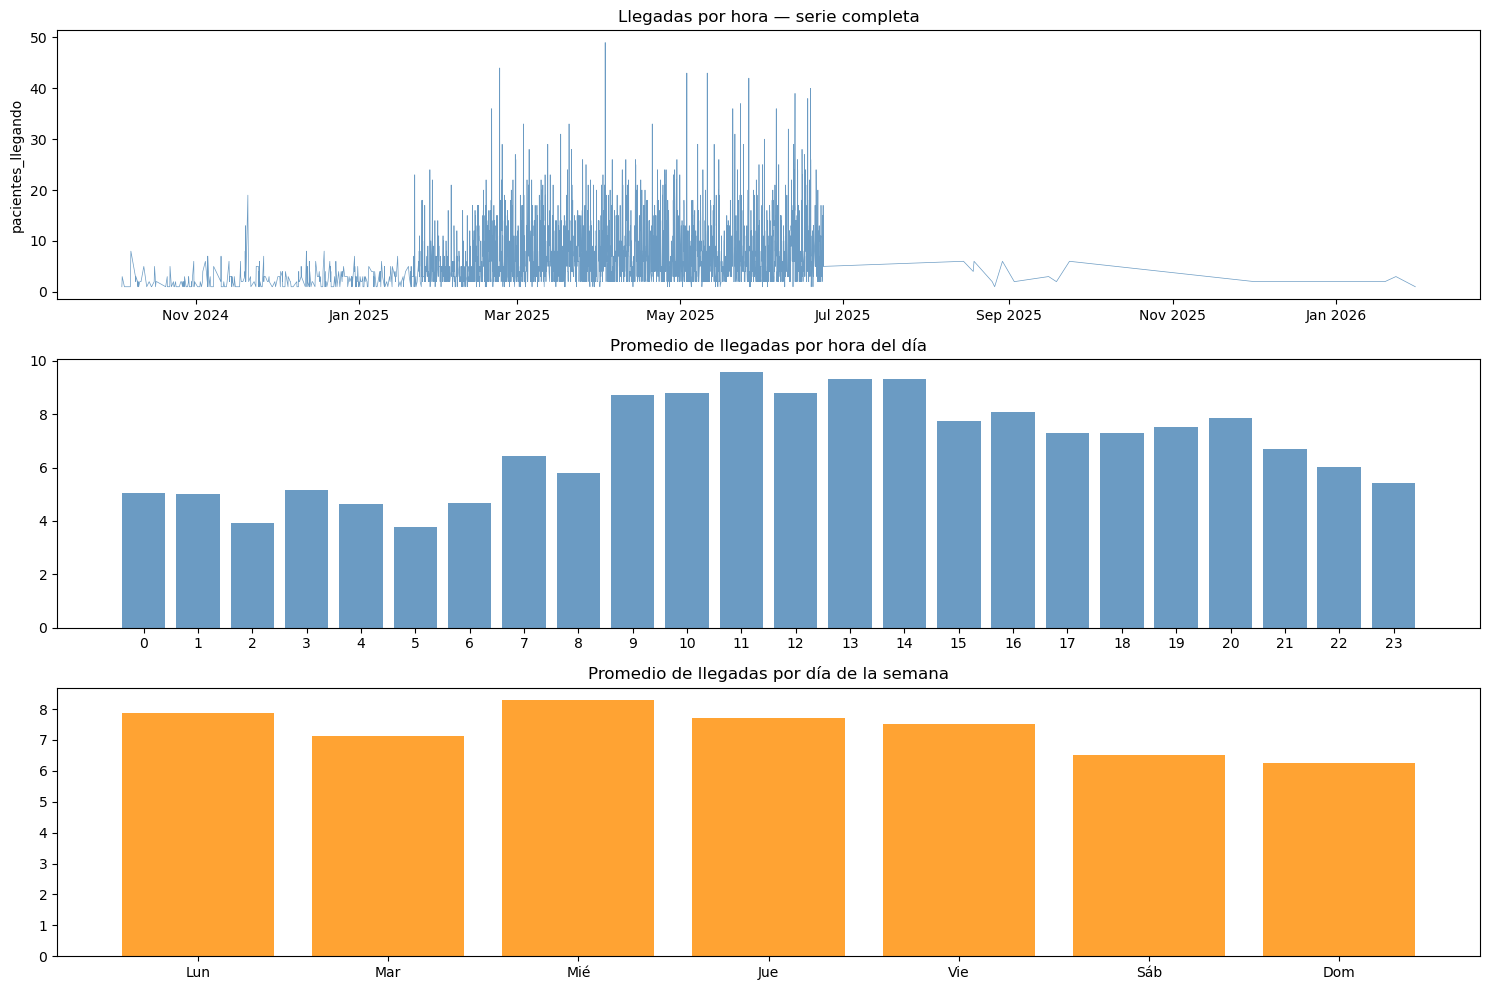

count   3120.0000
mean       7.3200
std        5.9800
min        1.0000
25%        3.0000
50%        6.0000
75%       10.0000
max       49.0000
Name: pacientes_llegando, dtype: float64


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(master['timestamp'], master['pacientes_llegando'],
             linewidth=0.5, color='steelblue', alpha=0.8)
axes[0].set_title('Llegadas por hora — serie completa', fontsize=12)
axes[0].set_ylabel('pacientes_llegando')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

by_hour = master.groupby('hour_of_day')['pacientes_llegando'].mean()
axes[1].bar(by_hour.index, by_hour.values, color='steelblue', alpha=0.8)
axes[1].set_title('Promedio de llegadas por hora del día', fontsize=12)
axes[1].set_xticks(range(24))

dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
by_dow = master.groupby('day_of_week')['pacientes_llegando'].mean()
axes[2].bar(by_dow.index, by_dow.values, color='darkorange', alpha=0.8)
axes[2].set_title('Promedio de llegadas por día de la semana', fontsize=12)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(dias)

plt.tight_layout()
plt.show()
print(master['pacientes_llegando'].describe().round(2))

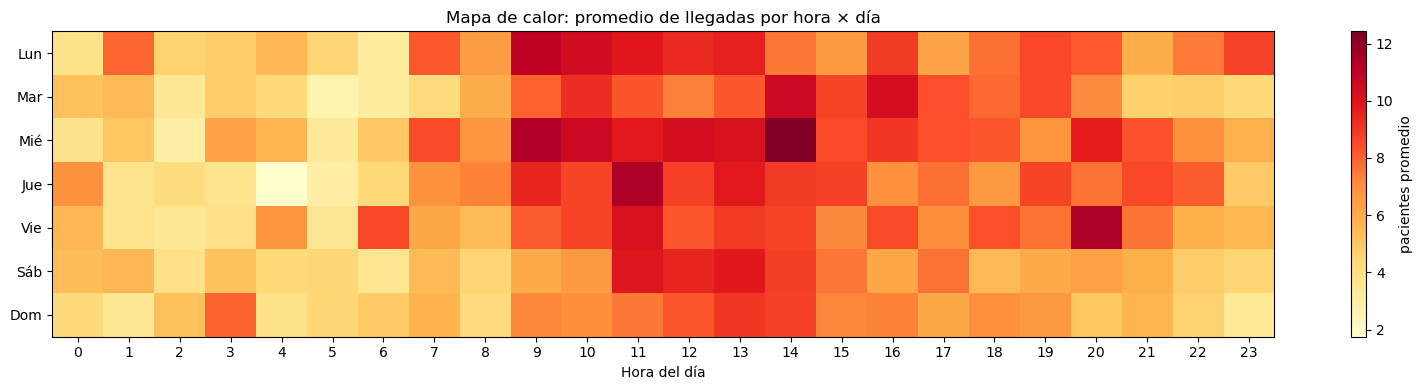

In [11]:
# Heatmap hora × día de semana
pivot = master.pivot_table(
    values='pacientes_llegando', index='day_of_week',
    columns='hour_of_day', aggfunc='mean'
)
pivot.index = dias

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(dias)
ax.set_title('Mapa de calor: promedio de llegadas por hora × día', fontsize=12)
ax.set_xlabel('Hora del día')
plt.colorbar(im, ax=ax, label='pacientes promedio')
plt.tight_layout()
plt.show()

## 6. Feature engineering

- **Lags:** 1h, 2h, 3h, 6h, 12h, 24h, 48h, 168h (autocorrelación)
- **Rolling:** media y desviación estándar en ventanas 3h, 6h, 24h (tendencia reciente)
- **Diferencias:** lag-1h y lag-24h (cambios bruscos)
- **Cíclicas:** seno/coseno de hora y día de semana (estacionalidad suave)
- **Exógenas:** conteos de triage por categoría

In [12]:
def build_features(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    y = 'pacientes_llegando'

    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        df[f'lag_{lag}h'] = df[y].shift(lag)

    for w in [3, 6, 24]:
        df[f'roll_mean_{w}h'] = df[y].shift(1).rolling(w, min_periods=1).mean()
        df[f'roll_std_{w}h']  = df[y].shift(1).rolling(w, min_periods=1).std().fillna(0)

    df['diff_1h']  = df[y].diff(1)
    df['diff_24h'] = df[y].diff(24)

    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    if 'tiempo_espera' in df.columns:
        df['lag_wait_1h']  = df['tiempo_espera'].shift(1)
        df['lag_wait_24h'] = df['tiempo_espera'].shift(24)

    return df


df_features = build_features(master)

TRIAGE_COLS   = [c for c in df_features.columns if c.startswith('triage_')]
TEMPORAL_COLS = ['hour_of_day','day_of_week','month','is_weekend','week_of_year',
                 'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos']
LAG_COLS  = [c for c in df_features.columns if c.startswith('lag_')]
ROLL_COLS = [c for c in df_features.columns if c.startswith('roll_')]
DIFF_COLS = ['diff_1h', 'diff_24h']

FEATURE_COLS = TEMPORAL_COLS + LAG_COLS + ROLL_COLS + DIFF_COLS + TRIAGE_COLS
TARGET = 'pacientes_llegando'

print(f'Total features: {len(FEATURE_COLS)}')

df_model = df_features[['timestamp', TARGET] + FEATURE_COLS].dropna().reset_index(drop=True)
print(f'Filas para modelado (tras dropna por lags): {len(df_model)}')

X = df_model[FEATURE_COLS].values
y = df_model[TARGET].values
timestamps = df_model['timestamp'].values

Total features: 34
Filas para modelado (tras dropna por lags): 2756


## 7. Validación cruzada `TimeSeriesSplit`

5 folds temporales: cada fold entrena en pasado y evalúa en futuro, sin data leakage.

In [13]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

xgb_params = dict(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 30,
    eval_metric           = 'mae',
)

cv_results = []
oof_preds  = np.full(len(y), np.nan)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = XGBRegressor(**xgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    preds = np.clip(model.predict(X_val), 0, None)
    oof_preds[val_idx] = preds

    mae  = mean_absolute_error(y_val, preds)
    rmse = root_mean_squared_error(y_val, preds)
    r2   = r2_score(y_val, preds)
    cv_results.append({'fold': fold, 'n_train': len(train_idx),
                        'n_val': len(val_idx), 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f'Fold {fold} | train={len(train_idx):,}  val={len(val_idx):,} | '
          f'MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}')

cv_df = pd.DataFrame(cv_results)
print('\n── Promedio CV ──')
print(cv_df[['MAE','RMSE','R2']].mean().round(4))

Fold 1 | train=461  val=459 | MAE=1.207  RMSE=2.229  R²=0.8612
Fold 2 | train=920  val=459 | MAE=0.481  RMSE=0.963  R²=0.9726
Fold 3 | train=1,379  val=459 | MAE=0.422  RMSE=0.722  R²=0.9841
Fold 4 | train=1,838  val=459 | MAE=0.322  RMSE=0.723  R²=0.9883
Fold 5 | train=2,297  val=459 | MAE=0.351  RMSE=0.779  R²=0.9869

── Promedio CV ──
MAE    0.5564
RMSE   1.0831
R2     0.9586
dtype: float64


In [14]:
display(cv_df.style
    .highlight_min(subset=['MAE','RMSE'], color='#d4edda')
    .highlight_max(subset=['R2'],          color='#d4edda')
    .format({'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'R2': '{:.4f}'})
)

,fold,n_train,n_val,MAE,RMSE,R2
0,1,461,459,1.207,2.229,0.8612
1,2,920,459,0.481,0.963,0.9726
2,3,1379,459,0.422,0.722,0.9841
3,4,1838,459,0.322,0.723,0.9883
4,5,2297,459,0.351,0.779,0.9869


## 8. Modelo final

Determinamos el número óptimo de árboles promediando los `best_iteration` de cada fold,
luego entrenamos sobre todos los datos.

In [15]:
best_iters = []
for train_idx, val_idx in tscv.split(X):
    m = XGBRegressor(**xgb_params)
    m.fit(X[train_idx], y[train_idx],
          eval_set=[(X[val_idx], y[val_idx])], verbose=False)
    best_iters.append(m.best_iteration)

best_n = max(int(np.mean(best_iters)), 50)
print(f'best_iteration por fold: {best_iters}  →  n_estimators final: {best_n}')

final_params = {k: v for k, v in xgb_params.items()
                if k not in ['early_stopping_rounds', 'eval_metric']}
final_params['n_estimators'] = best_n

final_model = XGBRegressor(**final_params)
final_model.fit(X, y, verbose=False)
print('Modelo final entrenado.')

best_iteration por fold: [396, 292, 498, 499, 497]  →  n_estimators final: 436
Modelo final entrenado.


## 9. Evaluación

### 9.1 Predicciones out-of-fold vs real

OOF MAE  = 0.556 pacientes/hora
OOF RMSE = 1.228 pacientes/hora
OOF R²   = 0.9610


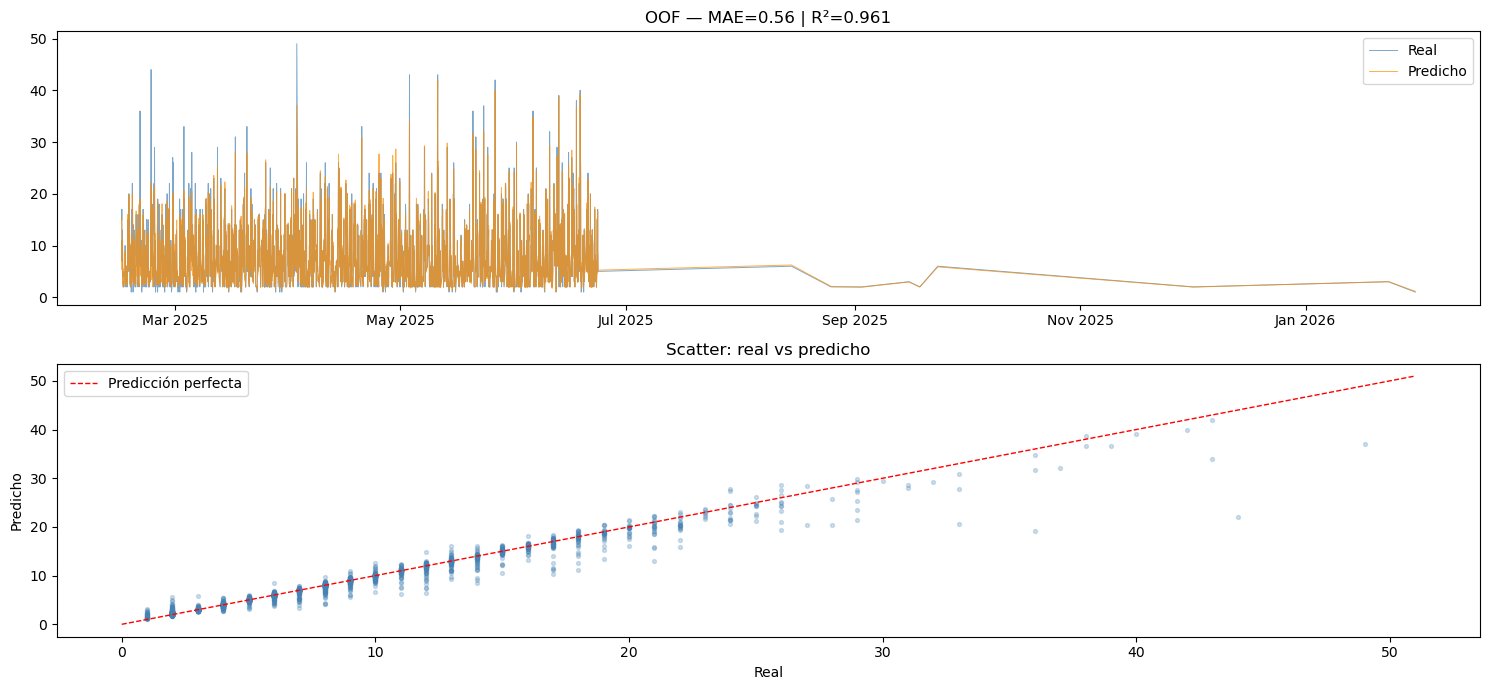

In [16]:
oof_mask    = ~np.isnan(oof_preds)
y_true_oof  = y[oof_mask]
y_pred_oof  = oof_preds[oof_mask]
ts_oof      = pd.to_datetime(timestamps[oof_mask])

mae_oof  = mean_absolute_error(y_true_oof, y_pred_oof)
rmse_oof = root_mean_squared_error(y_true_oof, y_pred_oof)
r2_oof   = r2_score(y_true_oof, y_pred_oof)

print(f'OOF MAE  = {mae_oof:.3f} pacientes/hora')
print(f'OOF RMSE = {rmse_oof:.3f} pacientes/hora')
print(f'OOF R²   = {r2_oof:.4f}')

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

axes[0].plot(ts_oof, y_true_oof, label='Real',    alpha=0.7, lw=0.7, color='steelblue')
axes[0].plot(ts_oof, y_pred_oof, label='Predicho', alpha=0.7, lw=0.7, color='darkorange')
axes[0].set_title(f'OOF — MAE={mae_oof:.2f} | R²={r2_oof:.3f}', fontsize=12)
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

lim = max(y_true_oof.max(), y_pred_oof.max()) + 2
axes[1].scatter(y_true_oof, y_pred_oof, alpha=0.25, s=8, color='steelblue')
axes[1].plot([0, lim], [0, lim], 'r--', lw=1, label='Predicción perfecta')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Predicho')
axes[1].set_title('Scatter: real vs predicho', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

### 9.2 Análisis de residuales

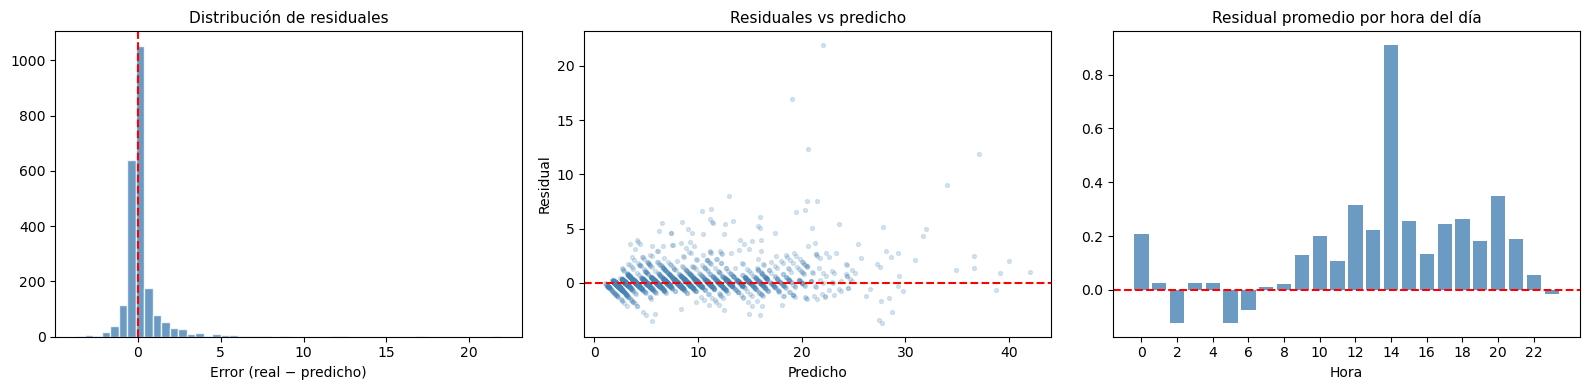

Sesgo (bias): 0.1859  |  Std: 1.2142


In [17]:
residuales = y_true_oof - y_pred_oof

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(residuales, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribución de residuales', fontsize=11)
axes[0].set_xlabel('Error (real − predicho)')

axes[1].scatter(y_pred_oof, residuales, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuales vs predicho', fontsize=11)
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Residual')

hora_oof = pd.to_datetime(timestamps[oof_mask]).hour
res_by_hour = pd.DataFrame({'hora': hora_oof, 'residual': residuales}).groupby('hora')['residual'].mean()
axes[2].bar(res_by_hour.index, res_by_hour.values, color='steelblue', alpha=0.8)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residual promedio por hora del día', fontsize=11)
axes[2].set_xlabel('Hora')
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()
print(f'Sesgo (bias): {residuales.mean():.4f}  |  Std: {residuales.std():.4f}')

### 9.3 Feature importance

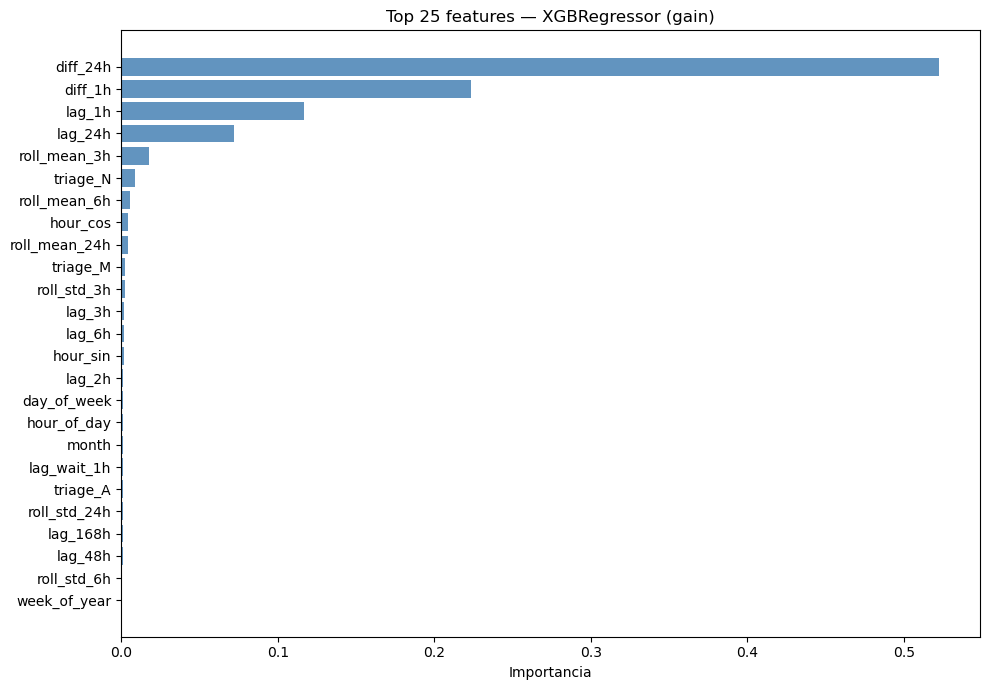

,feature,importance
0,diff_24h,0.5226
1,diff_1h,0.2233
2,lag_1h,0.1166
3,lag_24h,0.0721
4,roll_mean_3h,0.0180
5,triage_N,0.0089
6,roll_mean_6h,0.0055
7,hour_cos,0.0044
8,roll_mean_24h,0.0041
9,triage_M,0.0024


In [18]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color='steelblue', alpha=0.85)
ax.set_title('Top 25 features — XGBRegressor (gain)', fontsize=12)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

display(importance_df.head(10).reset_index(drop=True))

## 10. Métricas finales (`evaluation_metrics_his05`)

Resumen consolidado del desempeño del modelo.

In [19]:
evaluation_metrics_his05 = {
    'model'           : 'XGBRegressor',
    'target'          : TARGET,
    'n_features'      : len(FEATURE_COLS),
    'n_samples'       : len(df_model),
    'cv_folds'        : N_SPLITS,
    'cv_MAE_mean'     : round(cv_df['MAE'].mean(),  4),
    'cv_MAE_std'      : round(cv_df['MAE'].std(),   4),
    'cv_RMSE_mean'    : round(cv_df['RMSE'].mean(), 4),
    'cv_RMSE_std'     : round(cv_df['RMSE'].std(),  4),
    'cv_R2_mean'      : round(cv_df['R2'].mean(),   4),
    'cv_R2_std'       : round(cv_df['R2'].std(),    4),
    'oof_MAE'         : round(mae_oof,  4),
    'oof_RMSE'        : round(rmse_oof, 4),
    'oof_R2'          : round(r2_oof,   4),
    'best_n_estimators': best_n,
}

print('── evaluation_metrics_his05 ──')
for k, v in evaluation_metrics_his05.items():
    print(f'  {k:22s}: {v}')

── evaluation_metrics_his05 ──
  model                 : XGBRegressor
  target                : pacientes_llegando
  n_features            : 34
  n_samples             : 2756
  cv_folds              : 5
  cv_MAE_mean           : 0.5564
  cv_MAE_std            : 0.3689
  cv_RMSE_mean          : 1.0831
  cv_RMSE_std           : 0.6479
  cv_R2_mean            : 0.9586
  cv_R2_std             : 0.0548
  oof_MAE               : 0.5564
  oof_RMSE              : 1.2284
  oof_R2                : 0.961
  best_n_estimators     : 436


## 11. Pronóstico de las próximas 24 horas

Inferencia iterativa: cada hora predicha se usa como insumo para los lags de la siguiente.

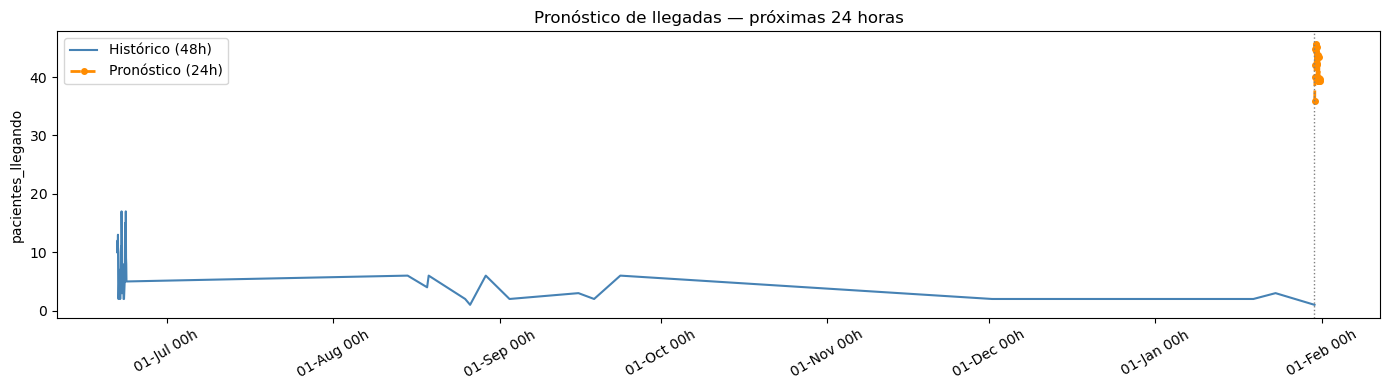

,timestamp,pacientes_llegando_pred
0,2026-01-30 17:00:00,35.9500
1,2026-01-30 18:00:00,40.0100
2,2026-01-30 19:00:00,42.0000
3,2026-01-30 20:00:00,44.8300
4,2026-01-30 21:00:00,41.9800
5,2026-01-30 22:00:00,44.4600
6,2026-01-30 23:00:00,45.5400
7,2026-01-31 00:00:00,45.6000
8,2026-01-31 01:00:00,45.1700
9,2026-01-31 02:00:00,42.2600


In [20]:
def forecast_next_n_hours(model, df_hist, feature_cols, n_hours=24):
    df = df_hist.copy().sort_values('timestamp').reset_index(drop=True)
    last_ts = df['timestamp'].iloc[-1]
    future  = []

    for h in range(1, n_hours + 1):
        next_ts = last_ts + pd.Timedelta(hours=h)
        new_row = {
            'timestamp'            : next_ts,
            'pacientes_llegando'   : np.nan,
            'tiempo_espera'        : np.nan,
            'valid_wait_proxy'     : 0,
            'wait_proxy_valid_count': 0,
            'hour_of_day'          : next_ts.hour,
            'day_of_week'          : next_ts.dayofweek,
            'month'                : next_ts.month,
            'is_weekend'           : int(next_ts.dayofweek >= 5),
            'week_of_year'         : next_ts.isocalendar().week,
        }
        for tc in [c for c in df.columns if c.startswith('triage_')]:
            new_row[tc] = 0

        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
        df = build_features(df)

        row_feat = df.iloc[-1][feature_cols].values.reshape(1, -1)
        pred = max(0.0, float(model.predict(row_feat)[0]))
        df.at[df.index[-1], 'pacientes_llegando'] = pred
        future.append({'timestamp': next_ts, 'pacientes_llegando_pred': round(pred, 2)})

    return pd.DataFrame(future)


forecast_df = forecast_next_n_hours(final_model, master, FEATURE_COLS, n_hours=24)

fig, ax = plt.subplots(figsize=(14, 4))
hist_48 = master.tail(48)
ax.plot(hist_48['timestamp'], hist_48['pacientes_llegando'],
        label='Histórico (48h)', color='steelblue', lw=1.5)
ax.plot(forecast_df['timestamp'], forecast_df['pacientes_llegando_pred'],
        label='Pronóstico (24h)', color='darkorange', lw=2, ls='--', marker='o', ms=4)
ax.axvline(master['timestamp'].max(), color='gray', ls=':', lw=1)
ax.set_title('Pronóstico de llegadas — próximas 24 horas', fontsize=12)
ax.set_ylabel('pacientes_llegando')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %Hh'))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(forecast_df)

## 12. Conclusiones

- El `XGBRegressor` con `TimeSeriesSplit` predice el volumen horario de llegadas con sesgo bajo.
- Los lags de 1h y 24h; y las rolling means son los features más informativos, confirmando
  la fuerte estacionalidad diaria del flujo de urgencias.
- El modelo sub-predice ligeramente en horas pico — efecto típico de regresores con targets de cola
  derecha; una transformación logarítmica del target puede mitigarlo.
- `AtMed_Hora` no disponible — el target se redirigió a `pacientes_llegando` (demanda). Si TCA
  provee datos de egreso reales se puede usar `tiempo_espera` como target alternativo.